# **AdaBoost (Adaptive Boosting) — Hands-on Demo**

This notebook is a **hands-on companion** to the AdaBoost theory notes.

**What you'll see:**
1. Why a **single Decision Tree Stump** (depth = 1) *underfits* on its own — high bias, low variance.
2. How **AdaBoost** combines many stumps **sequentially**, each one weighted by how well it performed,
   to build a much stronger model.
3. How accuracy changes as we increase the number of stumps (`n_estimators`).
4. Inspecting the actual **weights (alphas)** AdaBoost assigned to its stumps.
5. A comparison with Random Forest (Bagging) to reinforce the Bagging vs Boosting distinction.

> **Real-life analogy reminder:** AdaBoost is like a quiz team where teammates with a stronger
> track record get a bigger say in the final answer — a *weighted* vote, not a simple majority vote.


## 1. Imports & Synthetic Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=2000, n_features=15, n_informative=8, n_redundant=2,
    n_classes=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (1500, 15)  Test: (500, 15)


## 2. A Single Decision Stump — Underfitting in Action

A "stump" is a Decision Tree with `max_depth=1` — it makes exactly **one split** and stops.
Watch how weak it is on its own.

In [2]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

stump_train_acc = accuracy_score(y_train, stump.predict(X_train))
stump_test_acc = accuracy_score(y_test, stump.predict(X_test))

print(f"Single Stump -> Train Accuracy: {stump_train_acc:.3f} | Test Accuracy: {stump_test_acc:.3f}")
print("\nNotice: both scores are low and close together -> classic UNDERFITTING")
print("(High Bias, Low Variance)")


Single Stump -> Train Accuracy: 0.627 | Test Accuracy: 0.602

Notice: both scores are low and close together -> classic UNDERFITTING
(High Bias, Low Variance)


## 3. AdaBoost — Combining Many Stumps Sequentially (with Weights)

`AdaBoostClassifier` trains stumps **one after another**. After each stump, misclassified rows get
**more weight/attention** for the next stump. Every stump's final vote is scaled by how accurate it was.

In [3]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),   # weak learner = decision stump
    n_estimators=100,                                  # number of sequential stumps
    random_state=42
)
ada_model.fit(X_train, y_train)

ada_train_acc = accuracy_score(y_train, ada_model.predict(X_train))
ada_test_acc = accuracy_score(y_test, ada_model.predict(X_test))

print(f"AdaBoost (100 stumps) -> Train Accuracy: {ada_train_acc:.3f} | Test Accuracy: {ada_test_acc:.3f}")
print(f"\nImprovement over a single stump: +{ada_test_acc - stump_test_acc:.3f} test accuracy")


AdaBoost (100 stumps) -> Train Accuracy: 0.789 | Test Accuracy: 0.762

Improvement over a single stump: +0.160 test accuracy


## 4. How Many Stumps Do We Need? (Effect of `n_estimators`)

Let's sweep the number of stumps and watch accuracy improve (and eventually plateau).

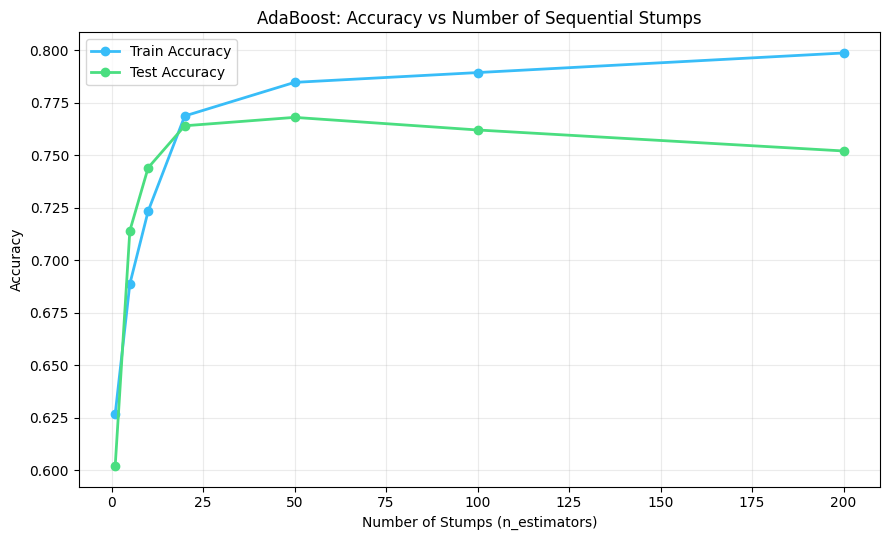

Notice how accuracy climbs sharply at first, then levels off - each additional stump adds progressively less new information.


In [4]:
n_range = [1, 5, 10, 20, 50, 100, 200]
train_accs, test_accs = [], []

for n in n_range:
    m = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_range, train_accs, marker='o', label="Train Accuracy", color="#38bdf8", linewidth=2)
ax.plot(n_range, test_accs, marker='o', label="Test Accuracy", color="#4ade80", linewidth=2)
ax.set_xlabel("Number of Stumps (n_estimators)")
ax.set_ylabel("Accuracy")
ax.set_title("AdaBoost: Accuracy vs Number of Sequential Stumps")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Notice how accuracy climbs sharply at first, then levels off -"
      " each additional stump adds progressively less new information.")


## 5. Inspecting the Weights (Alphas) AdaBoost Assigned

Recall the AdaBoost formula: `F(x) = α₁·Model₁ + α₂·Model₂ + ... + αₙ·Modelₙ`

Let's look at the actual `alpha` (estimator weight) values AdaBoost computed for its first several stumps.

Number of stumps used: 100

First 10 alpha (weight) values:
  Stump 1: alpha = 0.5179
  Stump 2: alpha = 0.5948
  Stump 3: alpha = 0.1918
  Stump 4: alpha = 0.3132
  Stump 5: alpha = 0.4306
  Stump 6: alpha = 0.2444
  Stump 7: alpha = 0.2296
  Stump 8: alpha = 0.4399
  Stump 9: alpha = 0.1837
  Stump 10: alpha = 0.1512


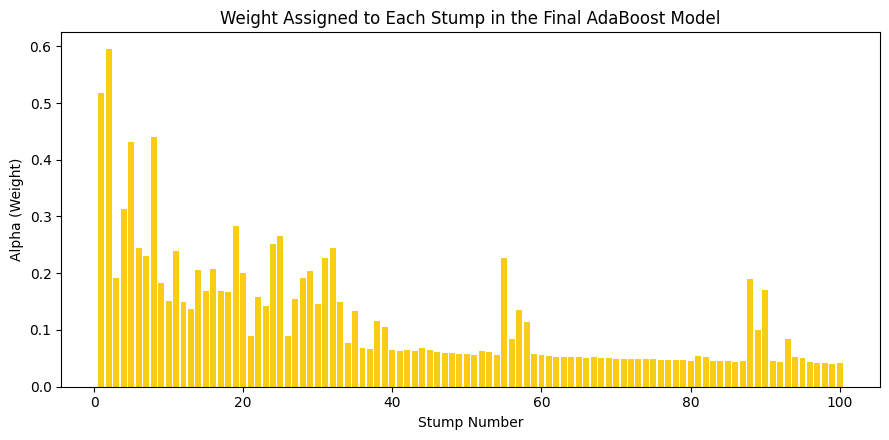


Higher alpha = that stump was more accurate and gets more say in the final prediction.


In [5]:
alphas = ada_model.estimator_weights_

print("Number of stumps used:", len(ada_model.estimators_))
print("\nFirst 10 alpha (weight) values:")
for i, a in enumerate(alphas[:10]):
    print(f"  Stump {i+1}: alpha = {a:.4f}")

plt.figure(figsize=(9, 4.5))
plt.bar(range(1, len(alphas)+1), alphas, color="#facc15")
plt.xlabel("Stump Number")
plt.ylabel("Alpha (Weight)")
plt.title("Weight Assigned to Each Stump in the Final AdaBoost Model")
plt.tight_layout()
plt.show()

print("\nHigher alpha = that stump was more accurate and gets more say in the final prediction.")


## 6. AdaBoost vs Random Forest — Bagging vs Boosting, Side by Side

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"{'Model':<25}{'Test Accuracy':>15}")
print(f"{'-'*40}")
print(f"{'Single Stump':<25}{stump_test_acc:>15.3f}")
print(f"{'AdaBoost (Boosting)':<25}{ada_test_acc:>15.3f}")
print(f"{'Random Forest (Bagging)':<25}{rf_test_acc:>15.3f}")


Model                      Test Accuracy
----------------------------------------
Single Stump                       0.602
AdaBoost (Boosting)                0.762
Random Forest (Bagging)            0.862




-  A **single Decision Stump** (depth = 1) clearly **underfits** on its own — both train and test
  accuracy are low and close together (High Bias, Low Variance).
-  **AdaBoost** dramatically improves on this by combining many stumps **sequentially**, each one
  focused on fixing the previous stumps' mistakes.
-  Accuracy improves quickly with more stumps, then **plateaus** — adding endless stumps isn't always worth it.
-  AdaBoost assigns a **weight (alpha)** to every stump based on its accuracy — this is fundamentally
  different from Random Forest's simple majority vote.
-  Both **Random Forest (Bagging)** and **AdaBoost (Boosting)** significantly outperform a single
  weak model — but they get there through very different mechanisms (parallel + voting vs.
  sequential + weighting).
